In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Set display options to show all columns
pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/OPIM 5604/listings.csv', encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
df.iloc[:, 61:80].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7522 entries, 0 to 7521
Data columns (total 18 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   estimated_occupancy_l365d                     7522 non-null   int64  
 1   estimated_revenue_l365d                       6373 non-null   float64
 2   first_review                                  6307 non-null   object 
 3   last_review                                   6307 non-null   object 
 4   review_scores_rating                          6307 non-null   float64
 5   review_scores_accuracy                        6305 non-null   float64
 6   review_scores_cleanliness                     6307 non-null   float64
 7   review_scores_checkin                         6306 non-null   float64
 8   review_scores_communication                   6307 non-null   float64
 9   review_scores_location                        6306 non-null   f

In [31]:
df.iloc[:, 61:80].head()

,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,10,620.0,2010-04-16,2025-03-07,4.89,4.95,4.87,4.97,4.98,4.68,4.91,"25-NSTR-11772, 25-OSTR-11151",f,1,1,0,0,2.73
1,255,38250.0,2011-02-16,2025-05-07,4.94,4.92,4.93,4.98,4.98,4.84,4.89,"21-RSTR-18609, 22-OSTR-20720",f,1,1,0,0,1.81
2,255,NaN,2011-05-03,2025-05-11,4.90,4.94,4.95,4.98,4.98,4.55,4.87,"23-NSTR-15067, 24-OSTR-20882",t,1,1,0,0,4.54
3,255,30855.0,2011-03-16,2025-03-05,4.96,4.95,4.99,4.99,4.99,4.84,4.94,"23-ISTR-02823, 23-OSTR-02823",f,1,1,0,0,2.91
4,255,20400.0,2011-03-24,2025-06-02,4.83,4.85,4.77,4.93,4.91,4.72,4.84,24-XSTR-08500,t,2,0,2,0,5.71


In [32]:
# --- STEP 1: PREVENT TARGET LEAKAGE ---
# Dropping 'estimated_revenue' because it is derived from Price * Occupancy.
# Including it would be cheating (Data Leakage).
df = df.drop(columns=['estimated_revenue_l365d'])

# --- STEP 2: DATE TRANSFORMATION ---
# Convert string dates to datetime objects
df['first_review'] = pd.to_datetime(df['first_review'])
df['last_review'] = pd.to_datetime(df['last_review'])

In [33]:
# Set a reference date (today) to calculate "Days Since"#
ref_date = pd.to_datetime('today')

In [34]:
# Calculate the difference in days. Fill NaNs with 0 (assuming 0 days of history if no reviews)
df['days_since_first_review'] = (ref_date - df['first_review']).dt.days.fillna(0)
df['days_since_last_review'] = (ref_date - df['last_review']).dt.days.fillna(0)

In [35]:
# Drop the original date columns as they are no longer needed
df = df.drop(columns=['first_review', 'last_review'])

In [36]:
# --- STEP 3: TEXT & BOOLEAN TRANSFORMATION ---
# Convert 't'/'f' to 1/0
df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0})

In [37]:
# Convert specific license text to a simple "Has License" (1) or "No License" (0)
df['has_license'] = df['license'].notnull().astype(int)
df = df.drop(columns=['license'])

In [38]:
# Check the new columns
print(df[['days_since_first_review', 'days_since_last_review', 'instant_bookable', 'has_license']].head())

   days_since_first_review  days_since_last_review  instant_bookable  \
0                   5786.0                   347.0                 0   
1                   5480.0                   286.0                 0   
2                   5404.0                   282.0                 1   
3                   5452.0                   349.0                 0   
4                   5444.0                   260.0                 1   

   has_license  
0            1  
1            1  
2            1  
3            1  
4            1  





*   **estimated_revenue_l365d**
This column was dropped from the dataset. Since the project goal is to predict "price," including estimated revenue would cause Data Leakage. Revenue is a direct calculation of Price × Occupancy; including it would allow the model to reverse-engineer the target variable rather than predicting it based on property attributes.
*   **first_review & last_review**
These columns contained raw date strings (e.g., "2019-01-01"), which regression models cannot process. We transformed these into numerical features: days_since_first_review and days_since_last_review. This creates a continuous variable representing the "age" of the listing's history and the "recency" of its activity. Missing values were imputed with 0.
*  **instant_bookable**
The original column was a categorical object using "t" and "f" strings. I recoded this into a binary integer format (1 for True, 0 for False) so it could be interpreted by the model.
*   **license**
This column contained high-cardinality text strings (specific permit numbers) which are unique to listings and offer no generalizable predictive power. However, the presence of a license is significant. I converted this into a binary has_license feature (1 if a license exists, 0 if null) and dropped the original text column.




In [39]:
# --- STEP 4: HANDLING MISSING REVIEW SCORES ---
# Define the list of review score columns
score_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

# Impute missing values with the median.
# We use median because ratings are left-skewed (mostly 4.5-5.0),
# so the mean would be misleading if there are low outliers.
for col in score_cols:
    df[col] = df[col].fillna(df[col].median())

# Handle 'reviews_per_month'
# If this is missing, it means there are 0 reviews, so the rate is 0/month.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


# --- STEP 5: REMOVING MULTICOLLINEARITY ---
# 'calculated_host_listings_count' is the sum of entire_homes + private_rooms + shared_rooms.
# We keep the total count and drop the sub-categories to avoid redundancy (Multicollinearity).
cols_to_drop = [
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]
df = df.drop(columns=cols_to_drop)

# Verify the changes
print(df[score_cols].info())
print(f"Remaining Columns: {df.columns.tolist()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7522 entries, 0 to 7521
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   review_scores_rating         7522 non-null   float64
 1   review_scores_accuracy       7522 non-null   float64
 2   review_scores_cleanliness    7522 non-null   float64
 3   review_scores_checkin        7522 non-null   float64
 4   review_scores_communication  7522 non-null   float64
 5   review_scores_location       7522 non-null   float64
 6   review_scores_value          7522 non-null   float64
dtypes: float64(7)
memory usage: 411.5 KB
None
Remaining Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbn

*   **review_scores_rating** (and all sub-scores)
These columns had approximately 1,290 missing values (approx. 17% of the data). Dropping these rows would result in significant data loss. Upon inspection, the distribution of review scores is heavily left-skewed, with the vast majority of ratings falling between 4.5 and 5.0. To preserve the data structure, we imputed these missing values using the median of each respective column. The median was chosen over the mean to avoid distortion from rare, extremely low ratings (1-star outliers).
*   **reviews_per_month**
Missing values in this column correspond to listings that have zero reviews. Therefore, a missing value logically equates to a rate of 0 reviews per month. We imputed these NaN values with 0.0.

*   **calculated_host_listings_count_**... (entire_homes, private_rooms, shared_rooms)
These three columns were dropped to prevent Multicollinearity. The dataset already contains calculated_host_listings_count, which is the aggregate sum of these three sub-categories. Including both the total and the constituent parts would provide the model with perfectly redundant information, which can destabilize regression coefficients. I retained only the total count variable.

Applied Yeo-Johnson Transform to: calculated_host_listings_count
Applied Yeo-Johnson Transform to: reviews_per_month
Applied Yeo-Johnson Transform to: number_of_reviews_ly
Applied Yeo-Johnson Transform to: estimated_occupancy_l365d


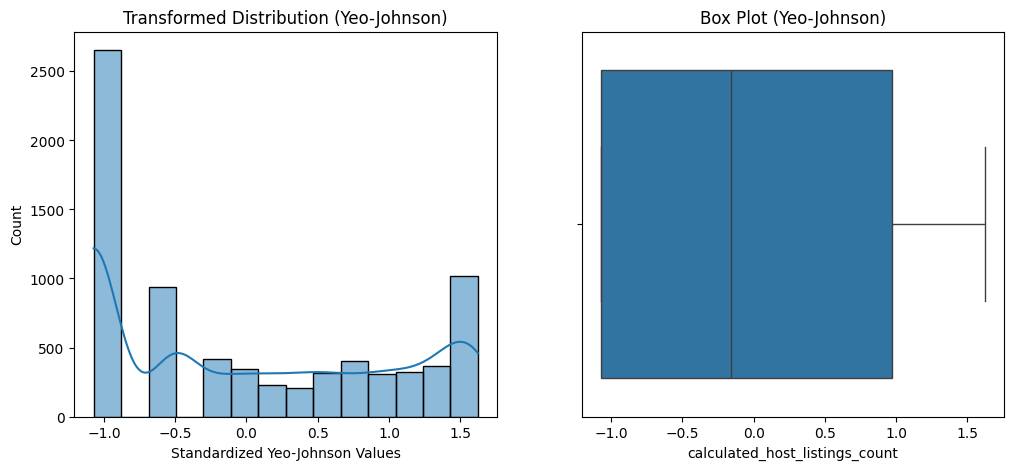

In [40]:
from sklearn.preprocessing import PowerTransformer

# --- STEP 6: ADVANCED TRANSFORMATION ---
# We use PowerTransformer with method='yeo-johnson'.
# It automatically finds the best parameter to make the data Normal.
# standardize=True also scales the data (Z-score)

cols_to_transform = [
    'calculated_host_listings_count',
    'reviews_per_month',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d'
]

# Initialize the transformer
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Loop through and transform each column
for col in cols_to_transform:
    # Reshape data to 2D array as required by sklearn
    col_data = df[[col]]

    # Fit and transform
    df[col] = pt.fit_transform(col_data)

    print(f"Applied Yeo-Johnson Transform to: {col}")

# --- VISUALIZATION CHECK ---
# Visualize the first column to see the result
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
sns.histplot(df['calculated_host_listings_count'], kde=True)
plt.title('Transformed Distribution (Yeo-Johnson)')
plt.xlabel('Standardized Yeo-Johnson Values')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['calculated_host_listings_count'])
plt.title('Box Plot (Yeo-Johnson)')
plt.show()

# --- STEP 7: FINAL EXPORT ---
df.to_csv('cleaned_airbnb_dataset.csv', index=False)

For the skewed variables calculated_host_listings_count, reviews_per_month, number_of_reviews_ly, and estimated_occupancy_l365d, we utilized the Yeo-Johnson Power Transformation.
Why:The Yeo-Johnson method automates the selection of the optimal power parameter to minimize skewness and maximize normality. Yeo-Johnson handles zero and negative values natively, which was essential for columns like reviews_per_month that contain zeros.
Standardization: we also enabled standardize=True, which centers the transformed data (mean = 0, variance = 1). This ensures that these high-variance features do not disproportionately influence the model weights due to scale differences.

We chose not to drop outliers because they represent valid, high-value data points (e.g., professional property managers). Removing them would have introduced Selection Bias, causing the model to underperform on high-revenue listings. Instead, we used the Yeo-Johnson transformation to normalize their impact while preserving their predictive signal.

Calculating correlation matrix...

--- FEATURES MOST CORRELATED WITH PRICE ---
price                             1.000000
calculated_host_listings_count    0.092245
instant_bookable                  0.091541
has_license                       0.044536
review_scores_rating              0.005463
days_since_last_review           -0.045351
days_since_first_review          -0.096002
number_of_reviews_ly             -0.103566
reviews_per_month                -0.127601
estimated_occupancy_l365d        -0.129957
Name: price, dtype: float64


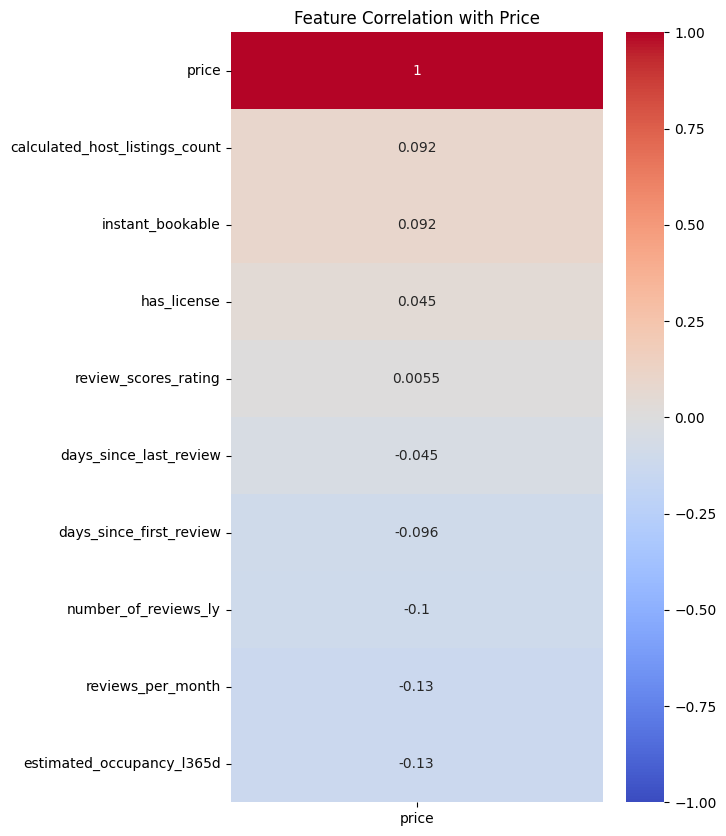

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 7: CLEANING AND CORRELATION ANALYSIS ---

# 1. Clean the 'price' column
# We remove '$' and ',' symbols so Python can treat price as a number
corr_df['price'] = corr_df['price'].astype(str).str.replace(r'[$,]', '', regex=True)
corr_df['price'] = pd.to_numeric(corr_df['price'], errors='coerce')

# 2. Convert text columns to numbers (1 and 0)
# 't' becomes 1 (True) and 'f' becomes 0 (False) so we can calculate correlation
bool_cols = ['instant_bookable', 'has_license']
for col in bool_cols:
    if col in corr_df.columns:
        corr_df[col] = corr_df[col].replace({'t': 1, 'f': 0, 'TRUE': 1, 'FALSE': 0, True: 1, False: 0})
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')

# 3. Final check to ensure all columns are numeric
# This prevents errors during the correlation calculation
for col in final_cols:
    if col in corr_df.columns:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')

# 4. Calculate the correlation matrix
# This shows how strongly each feature relates to others
print("Calculating correlation matrix...")
correlation = corr_df.corr()

# 5. Show which features have the strongest link to Price
# We sort them from highest to lowest correlation
price_corr = correlation['price'].sort_values(ascending=False)
print("\n--- FEATURES MOST CORRELATED WITH PRICE ---")
print(price_corr)

# 6. Create a Heatmap for visualization
# Red means positive correlation, Blue means negative
plt.figure(figsize=(6, 10))
sns.heatmap(correlation[['price']].sort_values(by='price', ascending=False),
            annot=True,     # Show the actual numbers on the map
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title("Feature Correlation with Price")
plt.show()

Correlation between 'review_scores_rating' and sub-scores:
review_scores_rating           1.000000
review_scores_value            0.851496
review_scores_accuracy         0.850091
review_scores_communication    0.770379
review_scores_cleanliness      0.769749
review_scores_checkin          0.680386
review_scores_location         0.577237
Name: review_scores_rating, dtype: float64


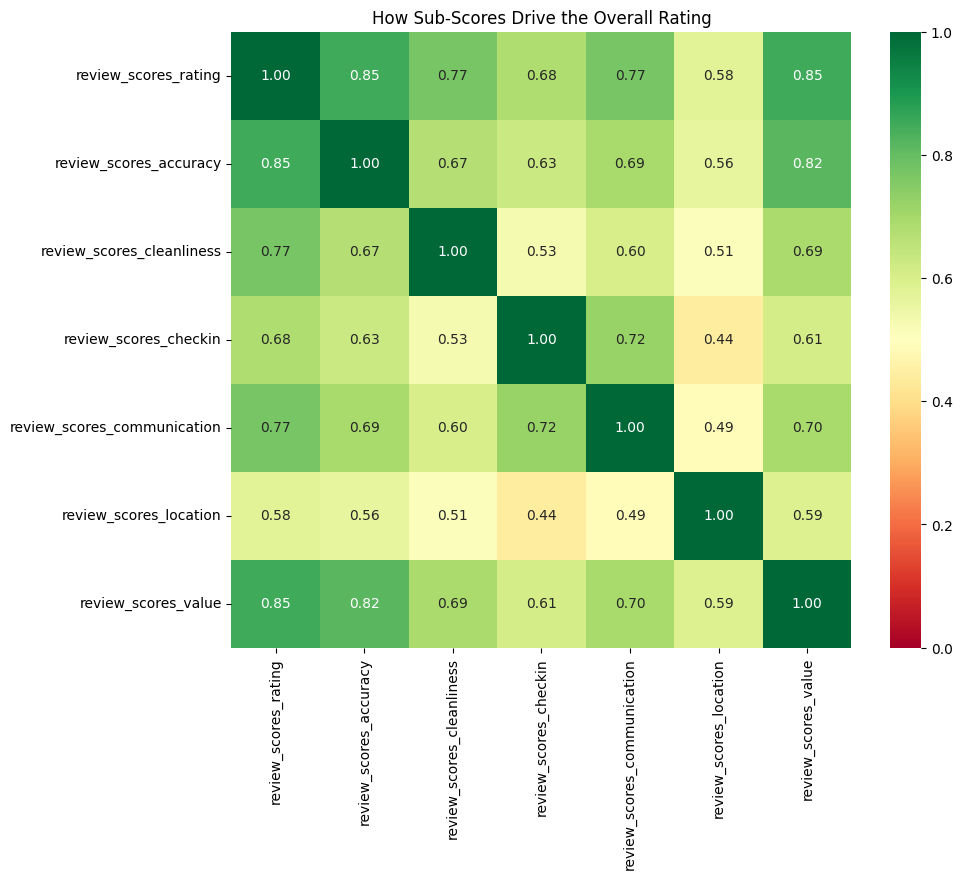

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 8: COMPARING REVIEW SUB-SCORES ---

# 1. Define the specific review columns we want to compare
# We want to see how the sub-scores relate to the overall rating
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

# 2. Filter the data and force everything to be a number
# If there is any text or empty data, this ensures it doesn't break our math
review_df = df[review_cols].apply(pd.to_numeric, errors='coerce')

# 3. Calculate the correlation between all review categories
# This tells us if categories are "twins" (telling the same story)
review_corr = review_df.corr()

# 4. Show the relationship between the Overall Rating and the others
# We sort them to see which category has the biggest impact on the total score
print("Correlation between 'review_scores_rating' and sub-scores:")
print(review_corr['review_scores_rating'].sort_values(ascending=False))

# 5. Create a Heatmap to visualize the relationships
# Green = Strong relationship, Red = Weak relationship
plt.figure(figsize=(10, 8))
sns.heatmap(review_corr,
            annot=True,      # Show the correlation numbers
            cmap='RdYlGn',   # Red-Yellow-Green color scheme
            fmt='.2f',       # Keep numbers to 2 decimal places
            vmin=0, vmax=1)  # Set the scale from 0 to 1
plt.title('How Sub-Scores Drive the Overall Rating')
plt.show()

We retained only review_scores_rating (the overall score) and dropped the specific sub-scores (accuracy, cleanliness, checkin, communication, location, value).
1. Addressing Multicollinearity (Internal Correlation Analysis)
Our heatmap analysis (Step 8) revealed a high degree of multicollinearity among the review columns. Specifically, the sub-scores (such as review_scores_accuracy and review_scores_communication) showed strong positive correlations with the overall review_scores_rating. This indicates that these features provide redundant information; a listing with high accuracy and communication scores almost invariably has a high overall rating. Keeping all of them would introduce noise and complexity without adding unique predictive value.

2. Low Correlation with Target (Price Correlation Analysis)
In our correlation matrix with the target variable price (Step 7), we observed that review scores generally have a weak linear relationship with price (coefficients near 0.0). This is expected, as both budget apartments and luxury estates can achieve "5-star" status. However, rather than removing all review metrics, we decided to keep review_scores_rating as a single proxy for "Guest Satisfaction." This preserves the ability of the model to penalize extremely poorly rated properties (non-linear relationship) while significantly reducing the dimensionality of our dataset by removing the six redundant sub-scores.

--- 1. MISSING VALUES CHECK ---
number_of_reviews_ly              0
estimated_occupancy_l365d         0
review_scores_rating              0
instant_bookable                  0
calculated_host_listings_count    0
reviews_per_month                 0
days_since_first_review           0
days_since_last_review            0
has_license                       0
dtype: int64

--- 2. DATA TYPE CHECK ---
number_of_reviews_ly              float64
estimated_occupancy_l365d         float64
review_scores_rating              float64
instant_bookable                    int64
calculated_host_listings_count    float64
reviews_per_month                 float64
days_since_first_review           float64
days_since_last_review            float64
has_license                         int64
dtype: object

--- 3. TRANSFORMATION CHECK (Skewness) ---
calculated_host_listings_count    0.316482
reviews_per_month                 0.095293
number_of_reviews_ly              0.115903
estimated_occupancy_l365d        -0.31

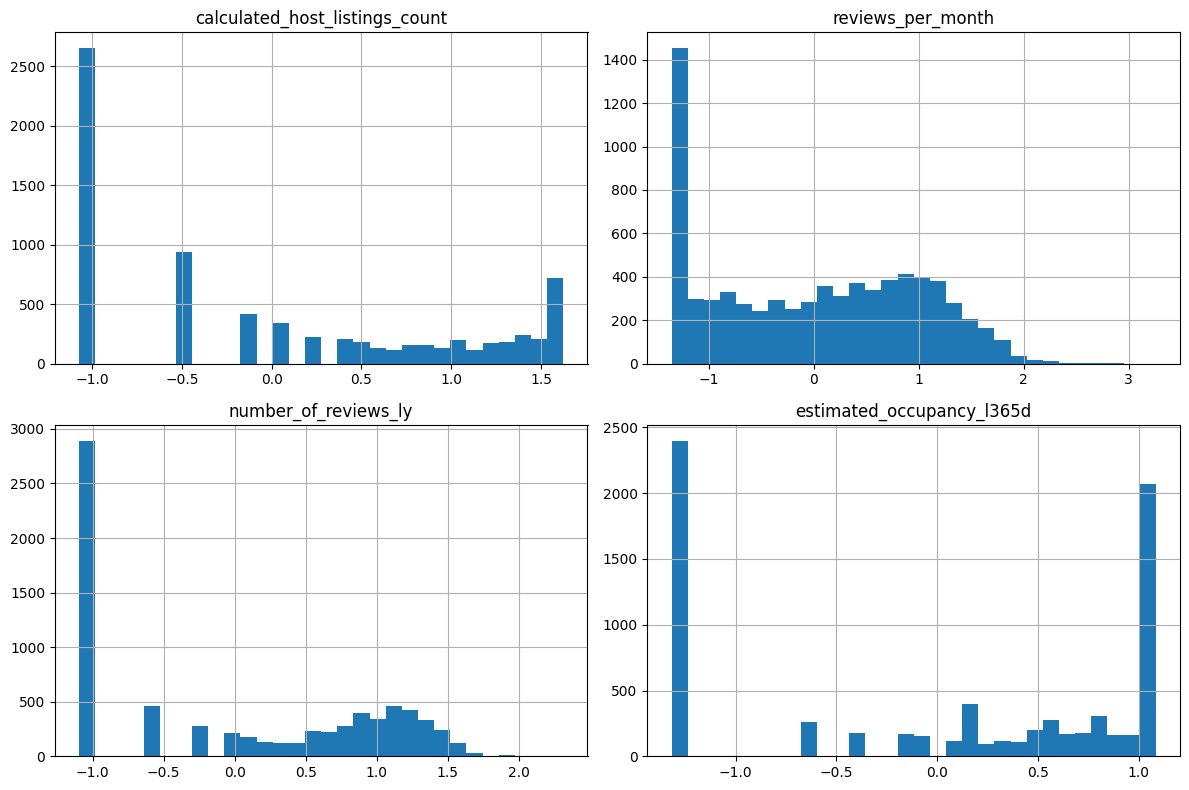

In [43]:
# --- FINAL VERIFICATION BLOCK ---

# 1. Define the columns we expect to have in the final dataset
final_cols = [
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
    'review_scores_rating',
    'instant_bookable',            # Should be 0 or 1
    'calculated_host_listings_count',
    'reviews_per_month',
    'days_since_first_review',     # Should be numeric
    'days_since_last_review',      # Should be numeric
    'has_license' # Should be 0 or 1
]

print("--- 1. MISSING VALUES CHECK ---")
print(df[final_cols].isnull().sum())

print("\n--- 2. DATA TYPE CHECK ---")
print(df[final_cols].dtypes)

print("\n--- 3. TRANSFORMATION CHECK (Skewness) ---")
# If Yeo-Johnson worked, these values should be close to 0 (between -0.5 and 0.5 is ideal)
transformed_vars = [
    'calculated_host_listings_count',
    'reviews_per_month',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d'
]
print(df[transformed_vars].skew())

print("\n--- 4. VISUAL PROOF (Histograms) ---")
# Plotting the transformed columns to confirm they look 'Normal-ish'
df[transformed_vars].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()